In [85]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

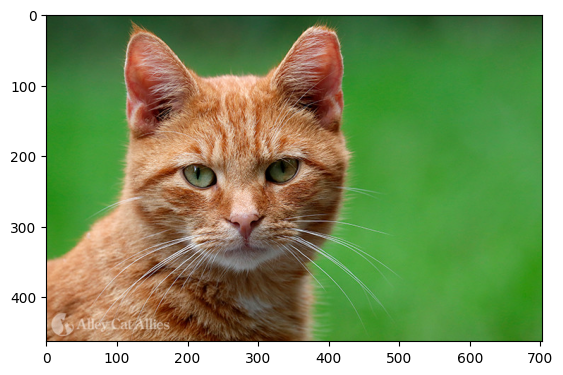

In [86]:
image = cv2.imread('cat.jpg')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Assignment- 3.1: : Understanding Convolution Basics

In [87]:
def conv2d(image, kernel):
    h, w, c = image.shape
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0,0)), 'constant')

    output = np.zeros((h, w, c))

    for ch in range(c):
        for i in range(h):
            for j in range(w):
                output[i, j, ch] = np.sum(
                    image[i:i+k_h, j:j+k_w, ch] * kernel
                )

    return output


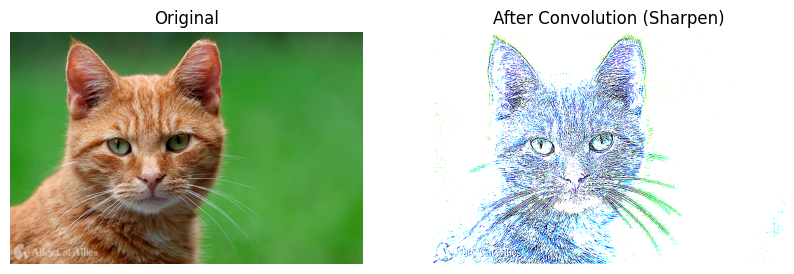

In [88]:
kernel = np.ones((3,3)) / 9

kernel = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
])


out_img = conv2d(image, kernel)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(out_img)
plt.title("After Convolution (Sharpen)")
plt.axis('off')

plt.show()

## 3.2: Image Smoothing Using Linear Filters

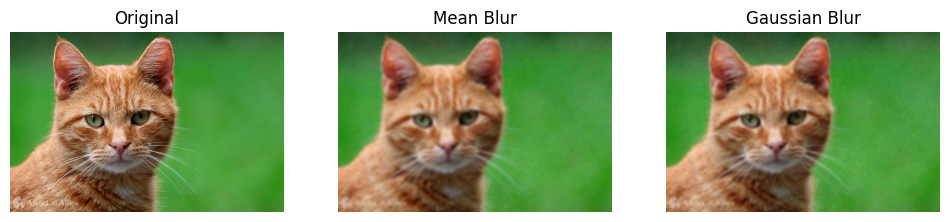

(np.float64(-0.5), np.float64(702.5), np.float64(462.5), np.float64(-0.5))

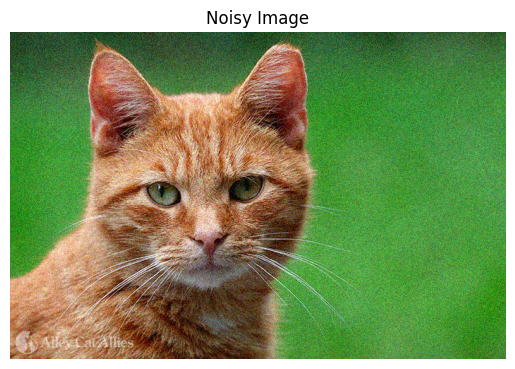

In [ ]:
noise = np.random.normal(0, 20, image.shape)
noisy = np.clip(image + noise, 0, 255).astype(np.uint8)

mean = cv2.blur(noisy, (9,9))
gaussian = cv2.GaussianBlur(noisy, (9,9), 3.0)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(mean, cv2.COLOR_BGR2RGB))
plt.title("Mean Blur")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis('off')

plt.show()

# show noisy image separately in correct colors
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
plt.title("Noisy Image")
plt.axis('off')


## Sharpening Images Using Spatial Filters

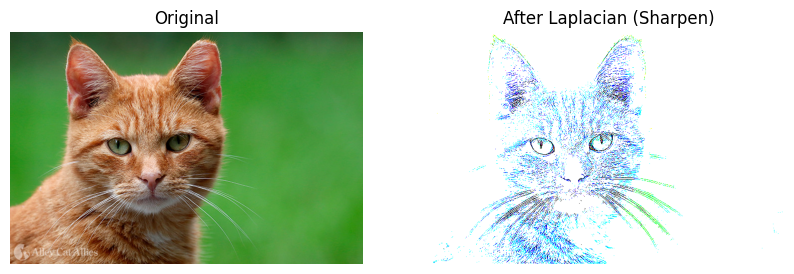

In [90]:
laplacian = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]])
edges = conv2d(image, laplacian)

sharpened = image + edges
sharpened = np.clip(sharpened, 0, 255)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sharpened)
plt.title("After Laplacian (Sharpen)")
plt.axis('off')

plt.show()

## Separable Filters and Computational Efficiency

PSNR between Gaussian and Sharpened: 31.693590711486106


(np.float64(-0.5), np.float64(702.5), np.float64(462.5), np.float64(-0.5))

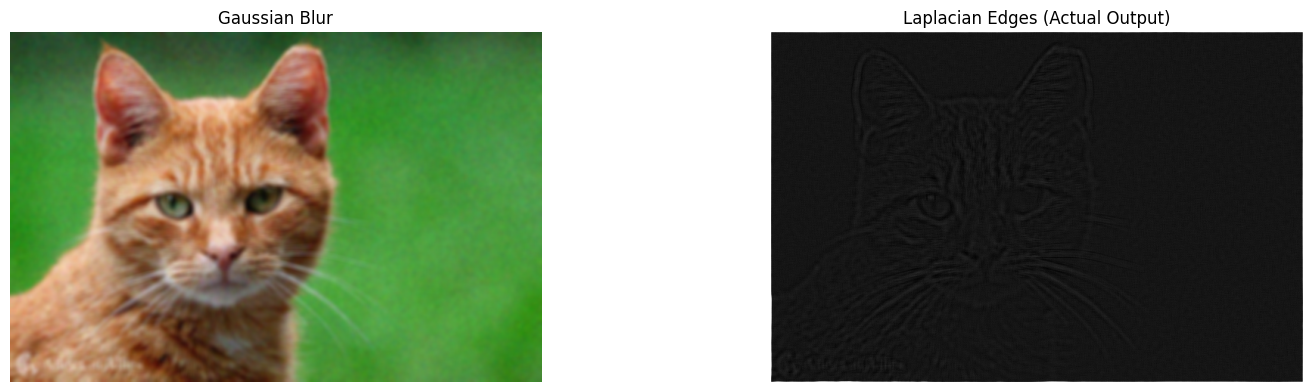

In [91]:
edges = conv2d(gaussian, laplacian)

sharpened = gaussian + edges
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

diff = np.abs(sharpened.astype(float) - gaussian.astype(float))

def psnr(a,b):
    mse = np.mean((a.astype(float)-b.astype(float))**2)
    return 10*np.log10(255*255/mse)

print("PSNR between Gaussian and Sharpened:",
      psnr(gaussian, sharpened))


plt.figure(figsize=(18,10))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(edges[:,:,0], cmap='gray')
plt.title("Laplacian Edges (Actual Output)")
plt.axis('off')



PSNR between SaltPepper and Sharpened: 16.445955354165736


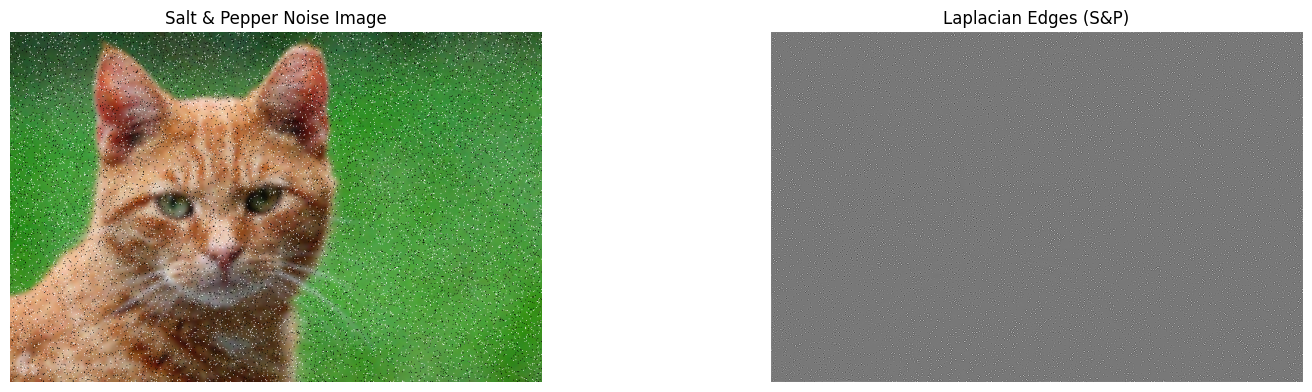

In [101]:
def add_salt_pepper(img, prob=0.02):
    noisy = img.copy()
    rnd = np.random.rand(img.shape[0], img.shape[1])

    mask_salt = rnd > 1 - prob
    mask_pepper = rnd < prob

    noisy[mask_salt] = [255,255,255]
    noisy[mask_pepper] = [0,0,0]
    return noisy

sp = add_salt_pepper(gaussian, prob=0.03)

edges_sp = conv2d(sp, laplacian)

sharpened_sp = sp.astype(float) + edges_sp.astype(float)
sharpened_sp = np.clip(sharpened_sp, 0, 255).astype(np.uint8)

diff_sp = np.abs(sharpened_sp.astype(float) - sp.astype(float))

print("PSNR between SaltPepper and Sharpened:",
      psnr(sp, sharpened_sp))

plt.figure(figsize=(18,10))

plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(sp, cv2.COLOR_BGR2RGB))
plt.title("Salt & Pepper Noise Image")
plt.axis('off')

plt.subplot(2,2,2)

if len(edges_sp.shape) == 3:
    show_edges = edges_sp[:,:,0]
else:
    show_edges = edges_sp

plt.imshow(show_edges, cmap='gray')
plt.title("Laplacian Edges (S&P)")
plt.axis('off')

plt.show()


## Separable Filters and Computational Efficiency

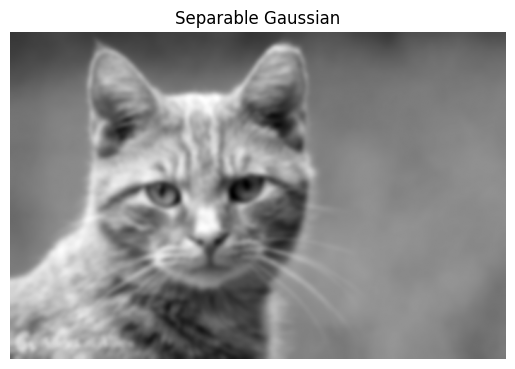

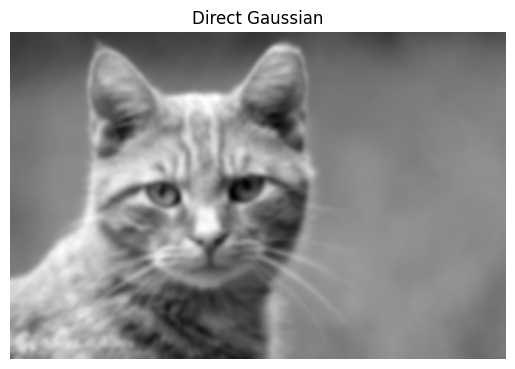

Separable time: 0.004663944244384766
Direct time: 0.005477428436279297
Max difference: 0.0


In [92]:
import cv2
import numpy as np
import time
from matplotlib import pyplot as plt

def show(img, title):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

img = cv2.imread('cat.jpg', 0)

img = img.astype(np.float32)

k = 29
sigma = 3

g1d = cv2.getGaussianKernel(k, sigma)

# Separable
start = time.time()
sep = cv2.sepFilter2D(img, -1, g1d, g1d)
t_sep = time.time() - start

# Direct
start = time.time()
direct = cv2.GaussianBlur(img, (k,k), sigma)
t_direct = time.time() - start

show(sep, "Separable Gaussian")
show(direct, "Direct Gaussian")

print("Separable time:", t_sep)
print("Direct time:", t_direct)

diff = np.abs(sep - direct)
print("Max difference:", diff.max())


## Non-Linear vs Linear Filtering

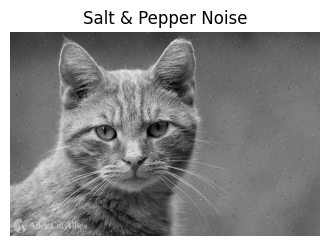

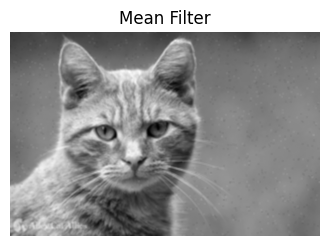

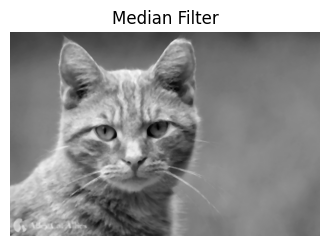

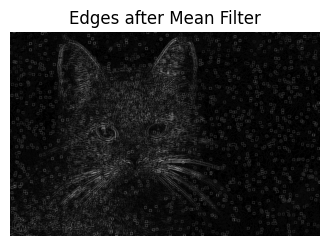

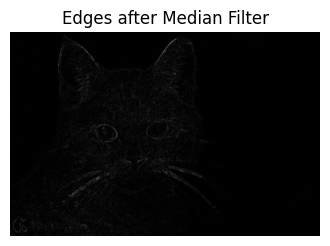

In [103]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

sp_noise = img.copy()

coords_salt = np.random.randint(0, img.size, 500)
coords_pepper = np.random.randint(0, img.size, 500)

sp_noise.flat[coords_salt] = 255
sp_noise.flat[coords_pepper] = 0


coords2 = np.random.randint(0, img.size, num_pixels)
sp_noise.flat[coords2] = 0

sp_noise_uint8 = sp_noise.astype(np.uint8)

mean = cv2.blur(sp_noise_uint8, (5,5))
median = cv2.medianBlur(sp_noise_uint8, 5)

show(sp_noise_uint8, "Salt & Pepper Noise")
show(mean, "Mean Filter")
show(median, "Median Filter")

edges_noisy  = cv2.Laplacian(sp_noise_uint8, cv2.CV_64F)
edges_mean   = cv2.Laplacian(mean, cv2.CV_64F)
edges_median = cv2.Laplacian(median, cv2.CV_64F)

show(np.abs(edges_mean), "Edges after Mean Filter")
show(np.abs(edges_median), "Edges after Median Filter")

